# Laboratorio 6 — Detección e investigación de valores atípicos

En el Laboratorio 5 describimos estadísticamente la variable `ventas` mediante medidas de posición y dispersión.

Ahora utilizaremos el **criterio del rango intercuartílico (IQR)** para identificar formalmente observaciones potencialmente atípicas.

## Objetivo

Aplicar el criterio de $1.5 \times IQR$ para:

- establecer límites inferior y superior;
- identificar transacciones potencialmente atípicas;
- representar su distribución mediante un boxplot;
- investigar las observaciones detectadas;
- diferenciar entre un valor **atípico** y un valor **incorrecto**.

## Pregunta central

> **¿Una observación identificada estadísticamente como atípica debe considerarse automáticamente un dato incorrecto?**

In [ ]:
import pandas as pd

df = pd.read_csv("/content/ventas_preparadas.csv")
q1 = df["ventas"].quantile(0.25)
q3 = df["ventas"].quantile(0.75)
iqr = q3 - q1
print(f"Q1:  ${q1:,.2f}")
print(f"Q3:  ${q3:,.2f}")
print(f"IQR: ${iqr:,.2f}")

Q1:  $90,350.00
Q3:  $311,820.00
IQR: $221,470.00


## 2. Establezcamos los límites para detectar valores potencialmente atípicos

Utilizaremos el criterio de $1.5 \times IQR$ para establecer dos límites:

$$
L_{\text{inferior}} = Q_1 - 1.5(IQR)
$$

$$
L_{\text{superior}} = Q_3 + 1.5(IQR)
$$

Una observación será considerada **potencialmente atípica** si:

$$
x < L_{\text{inferior}}
$$

o

$$
x > L_{\text{superior}}
$$

Calculemos estos límites para la variable `ventas`.

In [ ]:
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
print(f"Límite inferior: ${limite_inferior:,.2f}")
print(f"Límite superior: ${limite_superior:,.2f}")

Límite inferior: $-241,855.00
Límite superior: $644,025.00


### Interprete los límites

Los límites obtenidos mediante el criterio de $1.5 \times IQR$ son:

- **Límite inferior:** -$241.855

- **Límite superior:** $644.025

1. **¿Qué significa que el límite inferior sea negativo si las ventas registradas no presentan valores negativos?**  


2. **¿A partir de qué valor una transacción será considerada potencialmente atípica por encima de la distribución?**


3. **La transacción de $12.450.000 identificada en el Laboratorio 4, ¿cumple el criterio para ser considerada potencialmente atípica?**  


## 3. Identifiquemos las transacciones potencialmente atípicas

Ya establecimos los límites inferior y superior mediante el criterio de $1.5 \times IQR$.

Ahora filtraremos las observaciones que cumplen alguna de las siguientes condiciones:

$$
ventas < L_{\text{inferior}}
$$

o

$$
ventas > L_{\text{superior}}
$$

Estas observaciones serán clasificadas como **potencialmente atípicas**.

Recuerde: ser atípico estadísticamente **no significa que el dato sea incorrecto**.

In [ ]:
atipicos = df[
    (df["ventas"] < limite_inferior) |
    (df["ventas"] > limite_superior)
]
print(f"Total de transacciones: {len(df)}")
print(f"Transacciones potencialmente atípicas: {len(atipicos)}")

Total de transacciones: 4820
Transacciones potencialmente atípicas: 411


In [ ]:
porcentaje_atipicos = len(atipicos) / len(df) * 100
print(f"Transacciones potencialmente atípicas: {len(atipicos)}")
print(f"Porcentaje del conjunto: {porcentaje_atipicos:.2f}%")

Transacciones potencialmente atípicas: 411
Porcentaje del conjunto: 8.53%


### Interprete el resultado

El criterio del IQR identificó **411 transacciones potencialmente atípicas** de un total de **4.820**, equivalentes aproximadamente al **8,53% del conjunto**.

Responda:

1. **¿Qué significa que el 8,53% de las transacciones haya sido identificado como potencialmente atípico?**  

2. **¿Podemos afirmar que estas 411 transacciones son errores?**  

3. **¿Qué deberíamos hacer antes de decidir eliminar o modificar estas observaciones?**  

### Importante

El criterio del IQR permite **detectar observaciones que se encuentran alejadas del comportamiento central de la distribución**.

Sin embargo, la detección estadística no determina por sí sola si una observación es incorrecta.

Por esta razón, **un valor atípico debe investigarse antes de tomar una decisión sobre su eliminación o modificación**.

El siguiente paso será examinar las características de las **411 transacciones identificadas**.

## 4. Investiguemos las transacciones potencialmente atípicas

El criterio del IQR identificó **411 transacciones potencialmente atípicas**.

Sin embargo, conocer únicamente su cantidad no permite determinar por qué presentan valores elevados.

Ahora examinaremos algunas de estas transacciones junto con otras variables del conjunto de datos para buscar posibles explicaciones.

Comenzaremos observando las **10 transacciones potencialmente atípicas con mayor valor de venta**.

In [ ]:
columnas = [
    "fecha",
    "id_cliente",
    "producto",
    "categoria",
    "ciudad",
    "unidades",
    "precio_unitario",
    "descuento",
    "canal",
    "ventas"
]

atipicos.nlargest(10, "ventas")[columnas]

,fecha,id_cliente,producto,categoria,ciudad,unidades,precio_unitario,descuento,canal,ventas
1700,2025-12-25,14901,Portatil 14,Tecnologia,Medellin,500,3200000.0,0.0,Tienda,12450000.0
4391,2025-04-27,15041,Monitor 24,Tecnologia,Bogota,3,1574600.0,0.0,Tienda,4723800.0
630,2025-11-09,11063,Audifonos BT,Tecnologia,Cali,3,1367800.0,0.0,En linea,4103400.0
3075,2025-06-14,15654,Audifonos BT,Tecnologia,Cali,3,1683300.0,0.2,En linea,4039920.0
45,2025-03-10,13351,Audifonos BT,Tecnologia,Medellin,3,1102700.0,0.1,Tienda,2977290.0
2420,2025-06-20,13224,Teclado mecanico,Tecnologia,Bogota,3,961600.0,0.0,Tienda,2884800.0
283,2025-08-10,12619,Tablet 10,Tecnologia,Barranquilla,2,1415300.0,0.0,Tienda,2830600.0
1660,2025-03-05,18017,Portatil 14,Tecnologia,Cali,3,1007400.0,0.1,En linea,2719980.0
1201,2025-03-24,15932,Portatil 14,Tecnologia,Bogota,3,988500.0,0.1,En linea,2668950.0
3303,2025-07-13,16449,Tablet 10,Tecnologia,Barranquilla,2,1305800.0,0.0,Tienda,2611600.0


## 5. ¿En qué categorías se concentran las transacciones potencialmente atípicas?

La inspección de las transacciones de mayor valor mostró una presencia importante de productos de la categoría **Tecnología**.

Sin embargo, observar únicamente las primeras filas no es suficiente para concluir que este comportamiento se presenta en todas las transacciones potencialmente atípicas.

Analicemos ahora las **411 observaciones identificadas** y determinemos cómo se distribuyen entre las diferentes categorías.

In [ ]:
atipicos["categoria"].value_counts()

,count
categoria,
Tecnologia,365
Hogar,39
Moda,6
Deportes,1


### Interprete la distribución por categoría

De las 411 transacciones potencialmente atípicas identificadas:

- **Tecnología:** 365
- **Hogar:** 39
- **Moda:** 6
- **Deportes:** 1

1. **¿En qué categoría se concentra el mayor número de transacciones potencialmente atípicas?**  


2. **¿Podemos concluir únicamente con estos conteos que Tecnología presenta una mayor proporción de valores atípicos?**  


3. **¿Qué información adicional necesitamos para realizar una comparación adecuada entre categorías?**  


## 6. ¿Qué proporción de cada categoría fue identificada como atípica?

El número absoluto de transacciones potencialmente atípicas puede resultar engañoso si las categorías contienen diferentes cantidades de observaciones.

Por esta razón, compararemos:

- el número total de transacciones de cada categoría;
- el número de transacciones potencialmente atípicas;
- el porcentaje que estas representan dentro de cada categoría.

Esto permitirá determinar si la concentración observada en **Tecnología** se mantiene al considerar el tamaño de cada grupo.

In [ ]:
total_categoria = df["categoria"].value_counts()
atipicos_categoria = atipicos["categoria"].value_counts()
resumen_categoria = pd.DataFrame({
    "total_transacciones": total_categoria,
    "atipicos": atipicos_categoria
}).fillna(0)
resumen_categoria["porcentaje_atipicos"] = (
    resumen_categoria["atipicos"] /
    resumen_categoria["total_transacciones"] * 100
)
resumen_categoria.sort_values(
    "porcentaje_atipicos",
    ascending=False
)

,total_transacciones,atipicos,porcentaje_atipicos
categoria,,,
Tecnologia,813,365,44.895449
Hogar,1543,39,2.527544
Moda,1484,6,0.404313
Deportes,980,1,0.102041


### Interprete la proporción de valores atípicos

1. **¿Qué categoría presenta la mayor proporción de transacciones potencialmente atípicas?**  


2. **¿La concentración de valores atípicos en Tecnología puede explicarse porque sea la categoría con mayor número de transacciones?**  


3. **¿Qué diferencia existe entre afirmar que Tecnología tiene 365 valores atípicos y afirmar que el 44,90% de sus transacciones fue identificado como atípico?**  


4. **¿Podemos concluir que aproximadamente el 45% de las transacciones de Tecnología son incorrectas?**  


5. **¿Qué podría estar indicando este resultado sobre la aplicación de un único límite global a todas las categorías?**  


## 7. Representemos los valores potencialmente atípicos

Hasta ahora identificamos las observaciones potencialmente atípicas mediante cálculos numéricos.

Ahora utilizaremos un **diagrama de caja y bigotes (boxplot)** para representar visualmente la distribución de `ventas`.

En este gráfico podremos observar:

- la mediana;
- el rango intercuartílico;
- los bigotes;
- las observaciones que se encuentran fuera de los límites establecidos por el criterio del IQR.

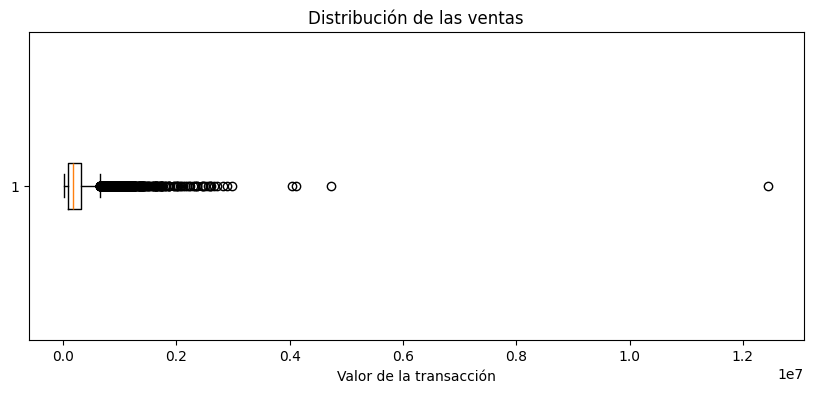

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.boxplot(df["ventas"], vert=False)

plt.xlabel("Valor de la transacción")
plt.title("Distribución de las ventas")

plt.show()

### Observe

1. **¿Qué observación está provocando principalmente la extensión del eje horizontal?**  


2. **¿Significa la presencia de numerosos puntos fuera del bigote que todos ellos sean datos incorrectos?**  


3. **¿Por qué resulta difícil observar la caja y los bigotes en esta representación?**  


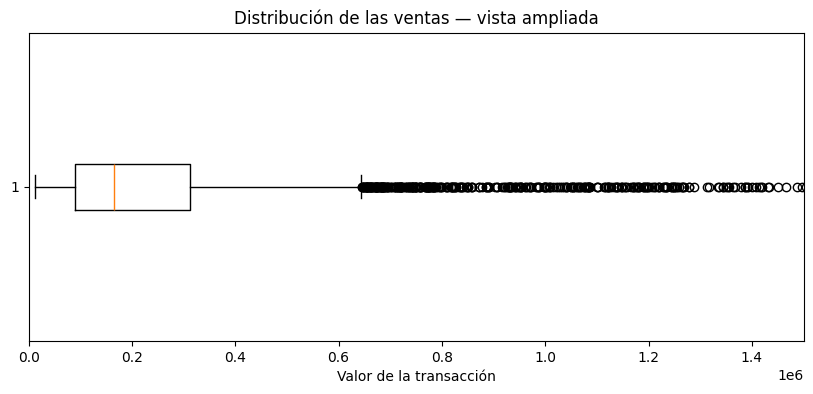

In [ ]:
plt.figure(figsize=(10, 4))
plt.boxplot(df["ventas"], vert=False)
plt.xlim(0, 1_500_000)
plt.xlabel("Valor de la transacción")
plt.title("Distribución de las ventas — vista ampliada")
plt.show()

### Compare las dos visualizaciones

El segundo boxplot muestra una **vista ampliada** de la distribución.

El uso de `xlim()` modifica únicamente la región visible del gráfico; **no elimina observaciones ni modifica los datos utilizados para construir el boxplot**.

1. **¿Qué elementos del boxplot pueden distinguirse con mayor claridad en la vista ampliada?**  


2. **¿A partir de qué valor aproximadamente comienzan a aparecer las observaciones potencialmente atípicas?**  

3. **¿Qué nos indica la gran cantidad de puntos ubicados hacia la derecha?**  


4. **¿La vista ampliada cambia cuáles observaciones fueron clasificadas como potencialmente atípicas?**  


## 8. Conclusiones del Laboratorio 6

1. **¿Cuántas transacciones fueron identificadas como potencialmente atípicas y qué porcentaje representan del conjunto?**

2. **¿En qué categoría se concentra la mayor cantidad de estas observaciones?**  

3. **¿Qué mostró el análisis de la proporción de valores atípicos dentro de cada categoría?**  


4. **¿Qué información aportó el boxplot al análisis?**  

5. **¿Podemos afirmar que las observaciones identificadas como atípicas son datos incorrectos? ¿Por qué?**  

### Conclusión

Escriba una conclusión solida basado en la informacion obtenida en el laboratorio

### Idea central

> **Un valor atípico es una señal para investigar, no una evidencia automática de error.**